# Time Series Exploration for INSPIRE data

## Importing Libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

## Defining Paths

In [2]:
inspire_path = Path("/home/server/Projects/data/INSPIRE/physionet.org/files/inspire/1.3")
ops_path = inspire_path / "operations.csv"
labs_path = inspire_path / "labs.csv"
vitals_path = inspire_path / "vitals.csv"
ward_vitals_path = inspire_path / "ward_vitals.csv"
combined_path = inspire_path / "combined_data.csv"
combined_cleaned_path = inspire_path / "combined_cleaned_data.csv"
pca_path = inspire_path / "pca_data.csv"
diagnosis_path = inspire_path / "diagnosis.csv"

## Exploring Vitals.csv
### CSV import as df_vitals

In [3]:
# Load the data
df_vitals = pd.read_csv(vitals_path.as_posix())

# Display basic information
print("\nDataFrame Shape:")
print(df_vitals.shape)

print("\nColumn Names:")
print(df_vitals.columns.tolist())

print("\nData Types:")
print(df_vitals.dtypes)

print("\nBasic Statistics:")
print(df_vitals.describe())

print("\nMissing Values:")
print(df_vitals.isnull().sum())

# Display first few rows
print("\nFirst 5 rows:")
print(df_vitals.head())


DataFrame Shape:
(66127940, 5)

Column Names:
['op_id', 'subject_id', 'chart_time', 'item_name', 'value']

Data Types:
op_id           int64
subject_id      int64
chart_time      int64
item_name      object
value         float64
dtype: object

Basic Statistics:
              op_id    subject_id    chart_time         value
count  6.612794e+07  6.612794e+07  6.612794e+07  6.612794e+07
mean   4.501949e+08  1.500362e+08  2.081616e+05  6.335775e+01
std    2.899169e+07  2.880297e+07  6.485078e+05  1.010078e+02
min    4.000005e+08  1.000008e+08 -1.440000e+03 -7.500000e+00
25%    4.249949e+08  1.251254e+08  2.260000e+03  9.500000e+00
50%    4.503567e+08  1.501092e+08  3.605000e+03  3.500000e+01
75%    4.754103e+08  1.749456e+08  9.470000e+03  8.000000e+01
max    4.999990e+08  1.999994e+08  5.185440e+06  6.468000e+03

Missing Values:
op_id         0
subject_id    0
chart_time    0
item_name     0
value         0
dtype: int64

First 5 rows:
       op_id  subject_id  chart_time item_name  value


In [4]:
df_ops = pd.read_csv(ops_path.as_posix())

# Display comprehensive overview
print("DataFrame Info:")
print(df_ops.info())

print("\nShape:", df_ops.shape)
print("\nColumns:", df_ops.columns.tolist())

print("\nData Types:")
print(df_ops.dtypes)

print("\nSummary Statistics:")
print(df_ops.describe())

print("\nMissing Values:")
print(df_ops.isnull().sum())

print("\nSample Data (First 5 rows):")
print(df_ops.head())

# Optional: Display unique values in categorical columns
print("\nUnique values in each column:")
for col in df_ops.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df_ops[col].value_counts().head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130960 entries, 0 to 130959
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   op_id                130960 non-null  int64  
 1   subject_id           130960 non-null  int64  
 2   hadm_id              130960 non-null  int64  
 3   case_id              21099 non-null   float64
 4   opdate               130960 non-null  int64  
 5   age                  130960 non-null  int64  
 6   sex                  130960 non-null  object 
 7   weight               129493 non-null  float64
 8   height               130172 non-null  float64
 9   race                 130960 non-null  object 
 10  asa                  127413 non-null  float64
 11  emop                 130960 non-null  int64  
 12  department           130960 non-null  object 
 13  antype               130960 non-null  object 
 14  icd10_pcs            130960 non-null  object 
 15  o

## Checking Diagnosis

In [3]:
# Load the data
df_diagnosis = pd.read_csv(diagnosis_path.as_posix())

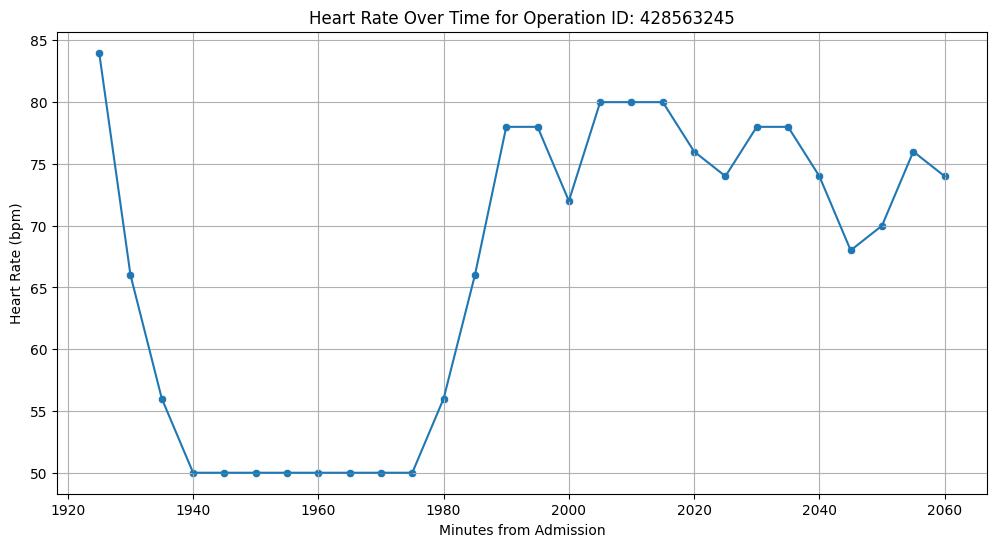


Basic statistics for this patient's heart rate:
count    28.000000
mean     66.571429
std      12.434804
min      50.000000
25%      50.000000
50%      71.000000
75%      78.000000
max      84.000000
Name: value, dtype: float64


In [5]:
# Filter data for heart rate measurements and specific operation
hr_data = df_vitals[
    (df_vitals['item_name'].str.contains('hr', case=False)) & 
    (df_vitals['op_id'] == 428563245)
].copy()

# Sort by chart_time
hr_data = hr_data.sort_values('chart_time')

# Create the plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=hr_data, x='chart_time', y='value')
sns.lineplot(data=hr_data, x='chart_time', y='value')

# Customize the plot
plt.title('Heart Rate Over Time for Operation ID: 428563245')
plt.xlabel('Minutes from Admission')
plt.ylabel('Heart Rate (bpm)')
plt.grid(True)

# Show the plot
plt.show()

# Display basic stats of the filtered data
print("\nBasic statistics for this patient's heart rate:")
print(hr_data['value'].describe())

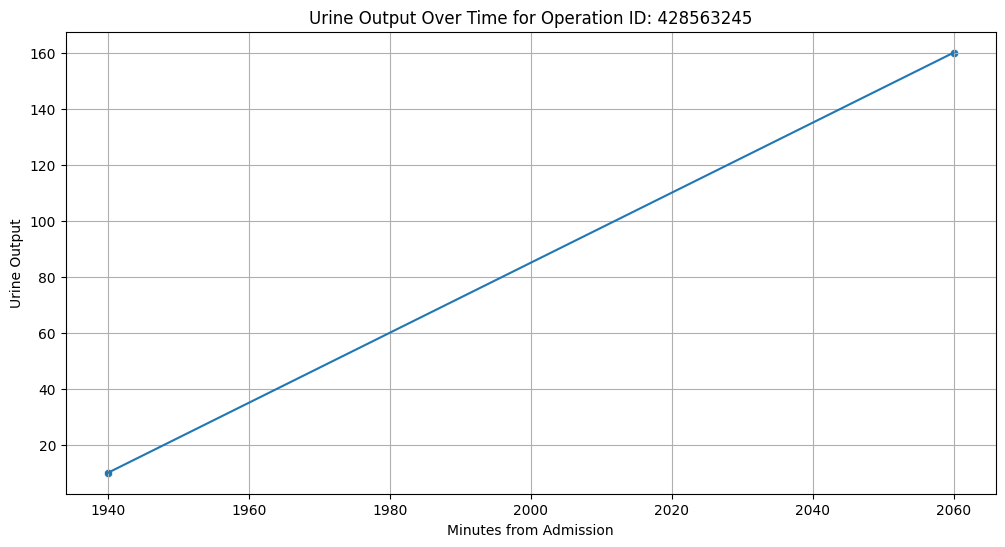


Basic statistics for urine output:
count      2.000000
mean      85.000000
std      106.066017
min       10.000000
25%       47.500000
50%       85.000000
75%      122.500000
max      160.000000
Name: value, dtype: float64


In [6]:
# Filter data for urine output measurements and specific operation
uo_data = df_vitals[
    (df_vitals['item_name'].str.contains('uo', case=False)) &
    (df_vitals['op_id'] == 428563245)
].copy()

# Sort by chart_time
uo_data = uo_data.sort_values('chart_time')

# Create the plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=uo_data, x='chart_time', y='value')
sns.lineplot(data=uo_data, x='chart_time', y='value')

# Customize the plot
plt.title('Urine Output Over Time for Operation ID: 428563245')
plt.xlabel('Minutes from Admission')
plt.ylabel('Urine Output')
plt.grid(True)
plt.show()

# Display basic statistics of the filtered data
print("\nBasic statistics for urine output:")
print(uo_data['value'].describe())

In [8]:

# Parameters
tolerance_lower = 4   # lower acceptable minutes
tolerance_upper = 6   # upper acceptable minutes
min_measurements = 3  # minimum measurements required per op_id
min_valid_diff_count = 5  # overall minimum count of intervals for a variable

# Filter out op_id groups with too few measurements
df_valid = df_vitals.copy()
op_counts = df_valid.groupby(['item_name', 'op_id'])['chart_time'].transform('count')
df_valid = df_valid[op_counts >= min_measurements]

# Sort by item_name, op_id and chart_time for diff computation
df_valid = df_valid.sort_values(['item_name', 'op_id', 'chart_time'])

# Compute time differences within each operation for each variable
df_valid['diff'] = df_valid.groupby(['item_name', 'op_id'])['chart_time'].diff()

# Drop rows with NaN differences (first measurement in each op_id)
df_diff = df_valid.dropna(subset=['diff'])

# Aggregate per variable (item_name)
agg_df = df_diff.groupby('item_name').agg(
    total_diffs=('diff', 'count'),
    count_within_range=('diff', lambda x: ((x >= tolerance_lower) & (x <= tolerance_upper)).sum())
)

# Only consider variables with enough total differences
agg_df = agg_df[agg_df['total_diffs'] >= min_valid_diff_count]

# Calculate ratio of differences that are within the tolerance range
agg_df['ratio'] = agg_df['count_within_range'] / agg_df['total_diffs']

# Select variables with at least 80% of intervals in the tolerance range
five_min_vars = agg_df[agg_df['ratio'] >= 0.8]

print("Variables generally collected every 5 minutes (>=80% within 4-6 minutes):")
print(five_min_vars[['ratio', 'total_diffs']])

Variables generally collected every 5 minutes (>=80% within 4-6 minutes):
              ratio  total_diffs
item_name                       
art_dbp    0.958562      2196282
art_mbp    0.951299      2308544
art_sbp    0.958154      2202596
bt         0.955344      3210685
cpat       0.998363      1633815
cvp        0.985941       899535
d10w       1.000000           20
etco2      0.978802      3655693
etgas      0.996914      1404023
fio2       0.981811      3504764
hr         0.854116      4582597
minvol     0.992348      3138827
n2o        0.894998         4838
nibp_dbp   0.920374      1918297
nibp_mbp   0.920342      1921485
nibp_sbp   0.920340      1918221
pap_dbp    0.979886       145424
pap_mbp    0.982583       163005
pap_sbp    0.978914       146688
peep       0.996346      2489036
pip        0.993153      3331585
pmean      0.996101      2799826
pplat      0.997936      1697405
spo2       0.988146      4094767
sti        0.991542       322773
stii       0.994409      2056589
st

## Surgical Department Type

In [3]:
# Python
import pandas as pd

# Load the operations data - defined by the ops_path in your notebook
df_ops = pd.read_csv(ops_path.as_posix())

# Get frequency counts for each department
dept_counts = df_ops['department'].value_counts()
print(dept_counts)

department
GS     34725
OS     17433
OT     17249
OG     12946
UR     12230
OL     11702
NS     10172
CTS     8754
PS      5157
RAD      379
IM        89
AN        68
PED       38
RO        15
EM         2
DM         1
Name: count, dtype: int64


## Check how many patients developed PNA within 30 days of procedure

In [ ]:
import pandas as pd

# Load the operations and diagnosis datasets
ops = pd.read_csv(ops_path)
diagnosis = pd.read_csv(diagnosis_path)

# Define 30 days in minutes
minutes_30_days = 30 * 24 * 60  # 43200 minutes

# Merge operations and diagnosis on patient identifier
merged = ops[['op_id', 'subject_id', 'opend_time']].merge(diagnosis, on='subject_id', how='inner')

# Specify pneumonia ICD-10-CM codes
pneumonia_codes = ['J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18']

# Filter merged data for pneumonia codes (checks if the diagnosis starts with one of the codes)
mask_codes = merged['icd10_cm'].astype(str).str.startswith(tuple(pneumonia_codes))
filtered = merged[mask_codes]

# Filter for diagnoses occurring within 30 days after the operation end time
mask_time = (filtered['chart_time'] >= filtered['opend_time']) & (filtered['chart_time'] <= (filtered['opend_time'] + minutes_30_days))
final_df = filtered[mask_time]

# Count unique patients with pneumonia
num_patients = final_df['subject_id'].nunique()
print("Number of patients with pneumonia within 30 days of procedure:", num_patients)

Number of patients with pneumonia within 30 days of procedure: 785


## Check PE outcome incidence

In [ ]:
import pandas as pd

# Load the operations and diagnosis datasets
ops = pd.read_csv(ops_path)
diagnosis = pd.read_csv(diagnosis_path)

# Define 30 days in minutes
minutes_30_days = 30 * 24 * 60  # 43200 minutes

# Merge operations and diagnosis on patient identifier
merged = ops[['op_id', 'subject_id', 'opend_time']].merge(diagnosis, on='subject_id', how='inner')

# Specify pneumonia ICD-10-CM codes
pe_codes = ['I26']

# Filter merged data for pneumonia codes (checks if the diagnosis starts with one of the codes)
mask_codes = merged['icd10_cm'].astype(str).str.startswith(tuple(pe_codes))
filtered = merged[mask_codes]

# Filter for diagnoses occurring within 30 days after the operation end time
mask_time = (filtered['chart_time'] >= filtered['opend_time']) & (filtered['chart_time'] <= (filtered['opend_time'] + minutes_30_days))
final_df = filtered[mask_time]

# Count unique patients with pulmonary embolism
num_patients = final_df['subject_id'].nunique()
print("Number of patients with pulmonary embolism within 30 days of procedure:", num_patients)

Number of patients with pneumonia within 30 days of procedure: 157


## Check MACE

In [7]:
import pandas as pd

# Load the operations and diagnosis datasets
ops = pd.read_csv(ops_path)
diagnosis = pd.read_csv(diagnosis_path)

# Define 30 days in minutes
minutes_30_days = 30 * 24 * 60  # 43200 minutes

# Merge operations and diagnosis on patient identifier
merged = ops[['op_id', 'subject_id', 'opend_time']].merge(diagnosis, on='subject_id', how='inner')

# Specify pneumonia ICD-10-CM codes
mace_codes = ['I21', 'I61', 'I63', 'I64', 'I69']

# Filter merged data for pneumonia codes (checks if the diagnosis starts with one of the codes)
mask_codes = merged['icd10_cm'].astype(str).str.startswith(tuple(mace_codes))
filtered = merged[mask_codes]

# Filter for diagnoses occurring within 30 days after the operation end time
mask_time = (filtered['chart_time'] >= filtered['opend_time']) & (filtered['chart_time'] <= (filtered['opend_time'] + minutes_30_days))
final_df = filtered[mask_time]

# Count unique patients with MACE
num_patients = final_df['subject_id'].nunique()
print("Number of patients with MACE within 30 days of procedure:", num_patients)

Number of patients with MACE within 30 days of procedure: 1158


In [6]:
import pandas as pd
from pathlib import Path

# Set the path to the INSPIRE database
inspire_path = Path("/home/server/Projects/data/INSPIRE/physionet.org/files/inspire/1.3")
ward_vitals_path = inspire_path / "ward_vitals.csv"

# Load the ward_vitals.csv file
df_ward_vitals = pd.read_csv(ward_vitals_path)

# List all unique variables under the 'item_name' column
unique_labels = df_ward_vitals['item_name'].unique()
print("Unique variables in 'item_name' (label) column:")
print(unique_labels)

# Calculate fill rate by patient for each variable
# Fill rate = number of patients with at least one measurement for this variable / total number of patients
total_patients = df_ward_vitals['subject_id'].nunique()
fill_rates = (
    df_ward_vitals.groupby('item_name')['subject_id']
    .nunique()
    .to_frame('num_patients_with_variable')
)
fill_rates['fill_rate'] = fill_rates['num_patients_with_variable'] / total_patients
# Sort by fill_rate descending
fill_rates = fill_rates.sort_values('fill_rate', ascending=False)
print("\nFill rate by variable (item_name) sorted:")
print(fill_rates)

Unique variables in 'item_name' (label) column:
['spo2' 'nibp_sbp' 'hr' 'nibp_dbp' 'bt' 'rr' 'nibp_mbp' 'crrt' 'ecmo' 'uo'
 'vent' 'gcs_e' 'gcs_m' 'gcs_v' 'fio2' 'iabp']

Fill rate by variable (item_name) sorted:
           num_patients_with_variable  fill_rate
item_name                                       
hr                              97977   0.990928
nibp_dbp                        97758   0.988713
nibp_sbp                        97758   0.988713
rr                              97713   0.988258
bt                              97707   0.988197
spo2                            95432   0.965188
uo                              47358   0.478973
nibp_mbp                        19388   0.196088
gcs_e                            8945   0.090469
gcs_m                            8945   0.090469
vent                             8945   0.090469
fio2                             8655   0.087536
gcs_v                            8557   0.086544
crrt                              855   0.008647
iab

In [5]:
# Merge ward vitals with operations to get operation end times
import pandas as pd
# Load operations data if not already in scope
if 'df_ops' not in globals():
    df_ops = pd.read_csv(ops_path.as_posix())
# Combine ward vitals with opend_time
df_wv_ops = df_ward_vitals.merge(
    df_ops[['subject_id', 'opend_time']], on='subject_id', how='left'
)
# Define pre-op and post-op subsets based on chart_time relative to opend_time
pre_op = df_wv_ops[df_wv_ops['chart_time'] <= df_wv_ops['opend_time']]
post_op = df_wv_ops[df_wv_ops['chart_time'] > df_wv_ops['opend_time']]
# Calculate pre-op fill rates
pre_rates = (
    pre_op.groupby('item_name')['subject_id']
    .nunique()
    .to_frame('num_preop_patients')
)
pre_rates['preop_fill_rate'] = pre_rates['num_preop_patients'] / total_patients
print("Pre-op fill rate by variable:")
print(pre_rates)
# Calculate post-op fill rates
post_rates = (
    post_op.groupby('item_name')['subject_id']
    .nunique()
    .to_frame('num_postop_patients')
)
post_rates['postop_fill_rate'] = post_rates['num_postop_patients'] / total_patients
print("\nPost-op fill rate by variable:")
print(post_rates)
# Combine both rates for comparison
combined_rates = pre_rates.join(
    post_rates, how='outer'
).fillna(0)
print("\nCombined pre- and post-op fill rates:")
combined_rates

Pre-op fill rate by variable:
           num_preop_patients  preop_fill_rate
item_name                                     
bt                      97442         0.985517
crrt                      328         0.003317
ecmo                       85         0.000860
fio2                     3470         0.035095
gcs_e                    3939         0.039839
gcs_m                    3939         0.039839
gcs_v                    3183         0.032192
hr                      97871         0.989856
iabp                      117         0.001183
nibp_dbp                97630         0.987418
nibp_mbp                 7929         0.080193
nibp_sbp                97631         0.987428
rr                      97458         0.985679
spo2                    55905         0.565417
uo                      45986         0.465097
vent                     3939         0.039839

Post-op fill rate by variable:
           num_postop_patients  postop_fill_rate
item_name                                  

,num_preop_patients,preop_fill_rate,num_postop_patients,postop_fill_rate
item_name,,,,
bt,97442,0.985517,96956,0.980602
crrt,328,0.003317,807,0.008162
ecmo,85,0.000860,151,0.001527
fio2,3470,0.035095,8494,0.085907
gcs_e,3939,0.039839,8765,0.088648
gcs_m,3939,0.039839,8764,0.088638
gcs_v,3183,0.032192,8302,0.083965
hr,97871,0.989856,97746,0.988592
iabp,117,0.001183,164,0.001659
